In [1]:
print("Alhamdullilah")

Alhamdullilah


1. Load Dataset
2. Basic EDA
3. Feature Selection
4. Visualization Before Clustering
5. Find Optimal K
6. Train Final K-Means Model
7. Visualization Cluster
8. Analyze Each Cluster
9. Business Recommendation

In [12]:
# 1. Load Dataset
import pandas as pd

df = pd.read_csv("data/Mall_Customers.csv")

print(df.info())
print(df.shape)
print(df.dtypes)
print(df.isnull().sum())
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   CustomerID     200 non-null    int64
 1   Gender         200 non-null    str  
 2   Age            200 non-null    int64
 3   AnnualIncome   200 non-null    int64
 4   SpendingScore  200 non-null    int64
dtypes: int64(4), str(1)
memory usage: 8.9 KB
None
(200, 5)
CustomerID       int64
Gender             str
Age              int64
AnnualIncome     int64
SpendingScore    int64
dtype: object
CustomerID       0
Gender           0
Age              0
AnnualIncome     0
SpendingScore    0
dtype: int64


,CustomerID,Age,AnnualIncome,SpendingScore
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


#### What we are trying to understand here
1. How many customers do we have?
2. What features are available?
3. Are there any missing values?
4. Are Numerical values in reasonable ranges?

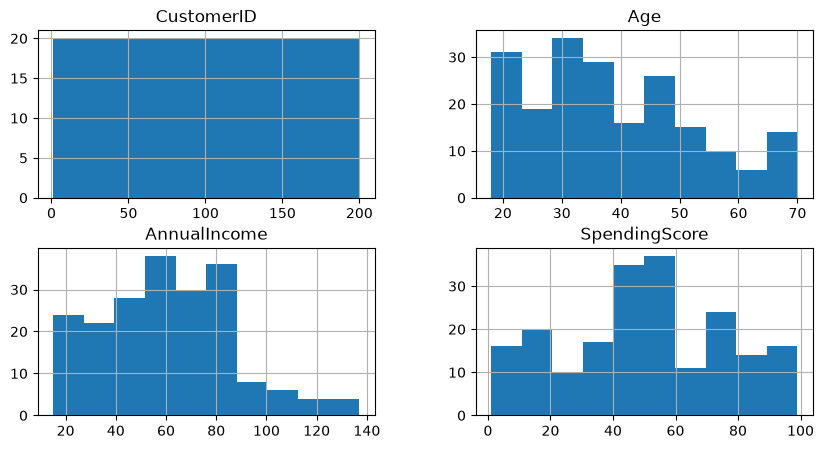

In [13]:
# Check Feature Distributions
import matplotlib.pyplot as plt

df.hist(figsize=(10, 5))
plt.show()

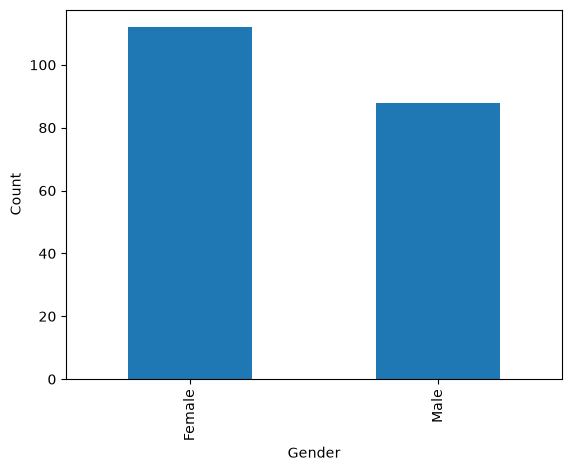

In [14]:
# Analyze gender distribution
df['Gender'].value_counts()

df['Gender'].value_counts().plot(kind='bar')

plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

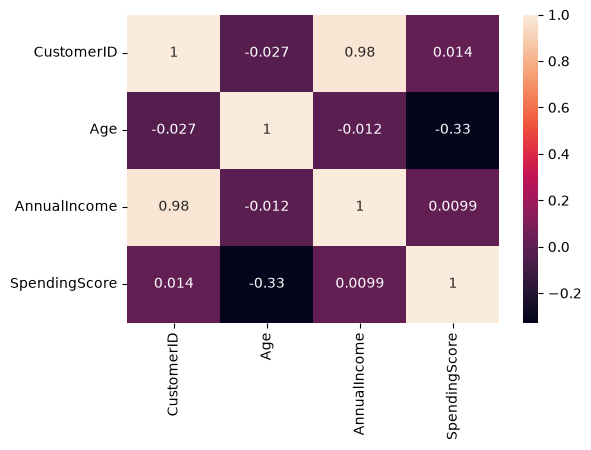

In [15]:
# Look at relationships between features
import seaborn as sns

plt.figure(figsize=(6,4))

sns.heatmap(
    df.select_dtypes('number').corr(),
    annot=True
)

plt.show()

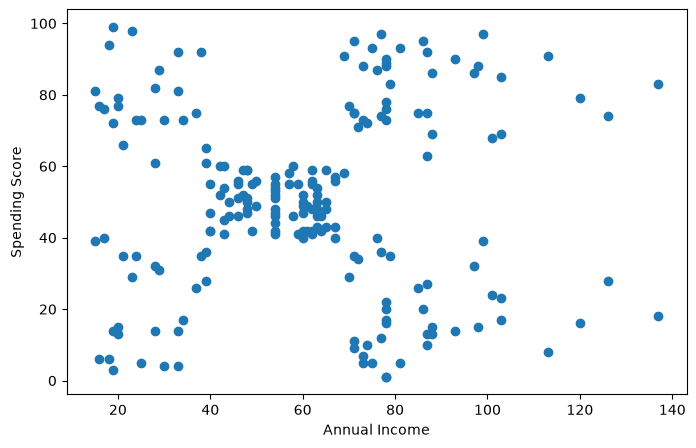

In [16]:
# The most important plot

plt.figure(figsize=(8, 5))

plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore']
)

plt.xlabel("Annual Income")
plt.ylabel("Spending Score")

plt.show()

In [17]:
# Select Features
X = df[['AnnualIncome', 'SpendingScore']]
X.head()

,AnnualIncome,SpendingScore
0,15,39
1,15,81
2,16,6
3,16,77
4,17,40


#### Find the optimal number of Cluster(K)

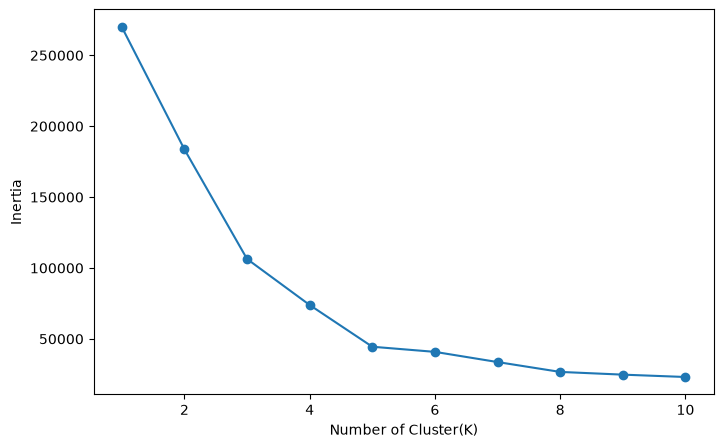

In [22]:
# Understand the inertia

from sklearn.cluster import KMeans

inertia = []
for k in range(1, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(X)

    inertia.append(kmeans.inertia_)
    # print(k, ": ", kmeans.inertia_)

plt.figure(figsize=(8, 5))

plt.plot(
    range(1,11),
    inertia,
    marker='o'
)

plt.xlabel("Number of Cluster(K)")
plt.ylabel("Inertia")

plt.show()

In [24]:
# This shows us K=5 is reasonable cluster

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(X)
df['Cluster'] = clusters

In [25]:
# Check Cluster Distribution
df['Cluster'].value_counts()

Cluster
0    81
1    39
3    35
4    23
2    22
Name: count, dtype: int64

In [27]:
# Get cluster centers
kmeans.cluster_centers_

array([[55.2962963 , 49.51851852],
       [86.53846154, 82.12820513],
       [25.72727273, 79.36363636],
       [88.2       , 17.11428571],
       [26.30434783, 20.91304348]])

#### Visualize Clusters and Understand Customer Segments

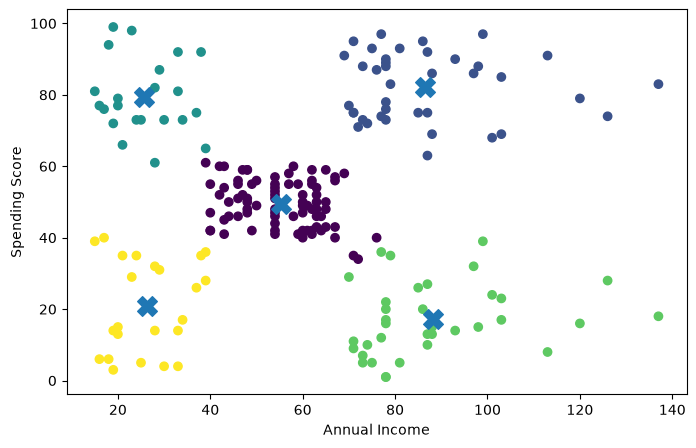

In [29]:
# Plot Customer by Cluster
plt.figure(figsize=(8, 5))
centers = kmeans.cluster_centers_

plt.scatter(
    df['AnnualIncome'],
    df['SpendingScore'],
    c=df['Cluster']
)

# Plot cluster centers
plt.scatter(
    centers[:, 0],
    centers[:, 1],
    marker='X',
    s=200
)

plt.xlabel('Annual Income')
plt.ylabel('Spending Score')

plt.show()

#### Understanding each cluster

In [40]:
cluster_summary = df.groupby('Cluster')[[
    'Age',
    'AnnualIncome',
    'SpendingScore'
]].mean()

cluster_summary
# df.groupby('Cluster').mean(numeric_only=True)

,Age,AnnualIncome,SpendingScore
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


In [41]:
cluster_summary =df.groupby('Cluster')[[
    'Age','AnnualIncome','SpendingScore'
]].mean()

cluster_summary

,Age,AnnualIncome,SpendingScore
Cluster,,,
0,42.716049,55.296296,49.518519
1,32.692308,86.538462,82.128205
2,25.272727,25.727273,79.363636
3,41.114286,88.200000,17.114286
4,45.217391,26.304348,20.913043


#### Evaluate Clustering Quality

In [42]:
# Silhouette Score
from sklearn.metrics import silhouette_score

silhouette_score = silhouette_score(
    X,
    df['Cluster']
)

print(silhouette_score)

0.553931997444648
